## Chapter 8 — ROM-Based Well-Test Parameter Estimation




In [1]:
import json, pickle, warnings, time, re
from pathlib import Path
import h5py, numpy as np, scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator
from scipy.stats import norm as sp_norm
from scipy.optimize import minimize
warnings.filterwarnings("ignore")
from matplotlib.lines import Line2D
import math
import matplotlib.cm as cm

plt.rcParams.update({
    'text.usetex': True, 'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
    'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 11, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': False, 'ytick.minor.visible': False,
    'axes.linewidth': 1, 'lines.linewidth': 1.8, 'lines.markersize': 6,
    'axes.grid': False, 'figure.dpi': 150, 'savefig.dpi': 600,
    'savefig.bbox': 'tight', 'legend.frameon': True,
    'legend.framealpha': 1.0, 'legend.edgecolor': 'black',
    'legend.fancybox': False,
})
C1="#1a5e9e"; C3="#9b2a1a"; C4="#b07318"
C_MRST="#2C5F8A"; C_INV="#1a7a4a"; C_GUESS="#b07318"
C_TRUE="#F3EF04"; C_NM="#8B0000"

_HERE        = Path(".").resolve()
TRAINING_DIR = _HERE / "../data/01_training"
VAL_DIR      = _HERE / "../data/02_validation"
ROM_DIR      = _HERE / "../rom_vrate"
FIG_DIR      = _HERE / "../figures_rom_inv"; FIG_DIR.mkdir(parents=True, exist_ok=True)
sf = lambda n: (plt.savefig(FIG_DIR/n, dpi=600, bbox_inches='tight'),
                print(f"  Saved: {FIG_DIR/n}"))

P_INIT=4500.; NX=NY=50; PHI=0.18; CT=1.2e-5; MU_CP=1.2; BO=1.15
H_FT=150.; C_WBS=0.003; RE_FT=(NX*30/2)*3.28084

def load_mat(fp, key):
    try: return sio.loadmat(str(fp), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(fp), "r") as f:
            a = f[key][()]; return a.T if a.ndim == 2 else a

def load_well_data(d):
    wd  = d/"well_data.mat"
    bhp = load_mat(wd,"bhp_psia").ravel(); t = load_mat(wd,"time_hr").ravel()
    q   = load_mat(wd,"rate_STBd").ravel(); dp = load_mat(wd,"delta_p_psi").ravel()
    with open(d/"params.json") as f: pm = json.load(f)
    return bhp, t, q, dp, pm

def physics_ok(k,s):
    kh=k*H_FT; tw=170000*C_WBS*MU_CP*np.exp(0.14*s)/kh
    tp=(PHI*MU_CP*CT*RE_FT**2)/(0.000264*k)*0.1
    return tw<5000 and tw<tp

def bourdet(t, dp, L=0.2):
    lnt=np.log(t); d=np.full_like(dp,np.nan)
    for i in range(1,len(t)-1):
        il,ir=i-1,i+1
        while il>0 and lnt[i]-lnt[il]<L: il-=1
        while ir<len(t)-1 and lnt[ir]-lnt[i]<L: ir+=1
        dl,dr=lnt[i]-lnt[il],lnt[ir]-lnt[i]
        if dl>0 and dr>0:
            d[i]=((dp[i]-dp[il])/dl*dr+(dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m=np.isfinite(d)&(d>0)&(dp>0); return t[m],dp[m],d[m]

# ROM loading
Vn=np.load(ROM_DIR/"basis"/"Vn.npy"); N_MODES=Vn.shape[1]
def _li(nm):
    with open(ROM_DIR/"interpolants"/f"{nm}_interp.pkl","rb") as f: obj=pickle.load(f)
    return obj["i"],obj["s"]
A_interps,A_shape=_li("A"); B_interps,B_shape=_li("B")
C_interps,C_shape=_li("C"); D_interps,D_shape=_li("D")

ops_dir=ROM_DIR/"operators"
# Discover training points from the operators directory (source of truth)
_op_dirs = sorted([d for d in ops_dir.iterdir()
                   if d.is_dir() and (d/"A_hat.npy").exists()])
_pat = re.compile(r'k(\d+)_s(\d+)')
valid = []
for d in _op_dirs:
    m = _pat.match(d.name)
    if m: valid.append((int(m.group(1)), int(m.group(2))))

pts    = np.array([[np.log10(k),s] for k,s in valid])
pts_min= pts.min(0); pts_rng=pts.max(0)-pts.min(0); pts_rng[pts_rng==0]=1.

def eval_op(interps,shape,k,s):
    pn=np.array([[(np.log10(k)-pts_min[0])/pts_rng[0],
                   (s-pts_min[1])/pts_rng[1]]])
    return np.array([f(pn)[0] for f in interps]).reshape(shape)

def _stab(A,m=1e-6):
    lr=np.max(np.real(np.linalg.eigvals(A)))
    return A-(lr+m)*np.eye(len(A)) if lr>=0 else A

def rom_bhp(k,s,t,q):
    A=_stab(eval_op(A_interps,A_shape,k,s))
    B=eval_op(B_interps,B_shape,k,s); C=eval_op(C_interps,C_shape,k,s)
    D=eval_op(D_interps,D_shape,k,s)
    dt=np.diff(t,prepend=0.); dt[0]=t[0]; In=np.eye(N_MODES)
    xk=np.zeros(N_MODES); Y=np.zeros(len(t))
    Cv=C.ravel(); Dv=float(D.ravel()[0])
    for j in range(len(t)):
        xk=np.linalg.solve(In-dt[j]*A, xk+dt[j]*B.ravel()*q[j])
        Y[j]=float(Cv@xk)+Dv*q[j]
    return P_INIT+Y

# Report what was discovered
K_train = sorted(set(k for k,s in valid))
S_train = sorted(set(s for k,s in valid))
print(f"ROM: {N_MODES} modes")
print(f"Training operators found: {len(valid)} pairs")
print(f"  k values: {K_train}")
print(f"  S values: {S_train}")


ROM: 15 modes
Training operators found: 36 pairs
  k values: [10, 20, 50, 100, 200, 300]
  S values: [0, 1, 2, 4, 6, 8]


In [2]:
# Discover every case folder in BOTH directories by scanning what exists on disk.
# No hardcoded grids — parse folder names directly.
# Folder naming convention: k{KKK}_s{SS}_sched{N}

_case_pat = re.compile(r'^k(\d+)_s(\d+)_sched(\d+)$')

def discover_cases(root, label):
    cases = []
    if not root.exists():
        print(f"  {label}: directory not found ({root})")
        return cases
    for d in sorted(root.iterdir()):
        if not d.is_dir(): continue
        m = _case_pat.match(d.name)
        if m and (d/"well_data.mat").exists():
            cases.append(dict(
                k=int(m.group(1)), s=int(m.group(2)), sched=int(m.group(3)),
                path=d, name=d.name, source=label
            ))
    return cases

train_cases = discover_cases(TRAINING_DIR, "TRAIN")
val_cases   = discover_cases(VAL_DIR,      "VAL")
all_cases   = val_cases + train_cases   # prefer validation (off-grid k,S)

# Summarise what was found
def summarise(cases, label):
    ks = sorted(set(c['k'] for c in cases))
    ss = sorted(set(c['s'] for c in cases))
    sc = sorted(set(c['sched'] for c in cases))
    print(f"\n{label}: {len(cases)} cases")
    print(f"  k      = {ks}")
    print(f"  S      = {ss}")
    print(f"  sched  = {sc}")

summarise(train_cases, "TRAINING")
summarise(val_cases,   "VALIDATION")
print(f"\nTotal to scan: {len(all_cases)} cases")



TRAINING: 252 cases
  k      = [10, 20, 50, 100, 200, 300]
  S      = [0, 1, 2, 4, 6, 8]
  sched  = [1, 2, 3, 4, 5, 6, 7]

VALIDATION: 759 cases
  k      = [10, 12, 15, 20, 25, 30, 35, 45, 50, 70, 75, 100, 150, 200, 250, 300]
  S      = [0, 1, 2, 3, 4, 5, 6, 7, 8]
  sched  = [1, 2, 3, 4, 5, 6, 7, 8, 9]

Total to scan: 1011 cases


In [3]:
# Compute ROM forward error for every discovered case.
# fwd_err = ||ROM(k,S,t,q) - FOM(k,S,t,q)|| / ||P_INIT - FOM||
# This is the true ROM accuracy at off-grid parameters with the actual
# rate schedule — no approximations, no assumptions.

print("Computing ROM forward error for all cases ...\n")
print(f"{'Case':<32} {'k':>5} {'S':>4} {'sc':>3} {'fwd_err':>9}  {'src'}")
print("-"*62)

candidates = []
for c in all_cases:
    try:
        bhp_fom, t, q, dp, pm = load_well_data(c['path'])
        bhp_rom  = rom_bhp(c['k'], c['s'], t, q)
        fwd_err  = (np.linalg.norm(bhp_rom - bhp_fom) /
                    (np.linalg.norm(P_INIT  - bhp_fom) + 1e-9))
        rec = {**c, 'fwd_err':fwd_err, 'bhp':bhp_fom,
               't':t, 'q':q, 'dp':dp, 'pm':pm}
        candidates.append(rec)
        print(f"  {c['name']:<30} {c['k']:>5} {c['s']:>4} {c['sched']:>3}"
              f" {fwd_err:>9.4f}  {c['source']}")
    except Exception as e:
        print(f"  {c['name']:<30}  ERROR: {e}")

candidates.sort(key=lambda x: x['fwd_err'])
print(f"\n{'─'*62}")
print(f"Total evaluated: {len(candidates)}")
print(f"\nBest 10 cases by ROM forward error:")
print(f"{'Case':<32} {'fwd_err':>9}  {'src'}")
for c in candidates[:10]:
    print(f"  {c['name']:<30} {c['fwd_err']:>9.4f}  {c['source']}")


Computing ROM forward error for all cases ...

Case                                 k    S  sc   fwd_err  src
--------------------------------------------------------------
  k010_s00_sched1                   10    0   1    0.0038  VAL
  k010_s00_sched2                   10    0   2    0.0040  VAL
  k010_s00_sched3                   10    0   3    0.0046  VAL
  k010_s00_sched4                   10    0   4    0.0038  VAL
  k010_s00_sched5                   10    0   5    0.0042  VAL
  k010_s00_sched6                   10    0   6    0.2872  VAL
  k010_s00_sched7                   10    0   7    0.0039  VAL
  k010_s01_sched1                   10    1   1    0.0017  VAL
  k010_s01_sched2                   10    1   2    0.0010  VAL
  k010_s01_sched3                   10    1   3    0.0032  VAL
  k010_s01_sched4                   10    1   4    0.0019  VAL
  k010_s01_sched5                   10    1   5    0.0023  VAL
  k010_s01_sched6                   10    1   6    0.2780  VAL
  k010_s

In [16]:
# """ # Selection strategy:
# #   1. Prefer VAL cases with S off training grid (S not in S_train) — genuine blind test
# #   2. Among those, pick lowest fwd_err
# #   3. Fall back to any VAL case, then any TRAIN case

# S_train_set = set(s for k,s in valid)
# K_train_set = set(k for k,s in valid)

# def is_off_grid(c):
#     return c['k'] not in K_train_set or c['s'] not in S_train_set

# # Try to pick an off-grid VAL case with low forward error
# pref = [c for c in candidates if c['source']=='VAL' and is_off_grid(c)]
# if not pref:
#     pref = [c for c in candidates if c['source']=='VAL']
# if not pref:
#     pref = candidates

# case = pref[89]   # already sorted by fwd_err
# bhp_obs=case['bhp']; t_obs=case['t']; q_obs=case['q']
# K_TRUE=case['k'];    S_TRUE=case['s']
# q_ref=float(np.atleast_1d(case['pm']['rates_STBd'])[0])
# off_grid_str = ("off-grid k,S" if is_off_grid(case) else "on-grid (training point)")

# print(f"Selected: {case['name']}  [{case['source']}, {off_grid_str}]")
# print(f"  k={K_TRUE} mD, S={S_TRUE}, sched={case['sched']}, q_ref={q_ref:.0f} STB/d")
# print(f"  ROM fwd_err = {case['fwd_err']:.4f}")
# print(f"  t=[{t_obs[0]:.3f},{t_obs[-1]:.0f}] hr, {len(t_obs)} pts") """

# # ══ MANUAL PARAMETER ENTRY ════════════════════════════════════════════════
# K_MANUAL = 30.0
# S_MANUAL = 5.0
# SCHED_MANUAL = 1

# # Construct the folder name
# folder_name = f"k{int(K_MANUAL):03d}_s{int(S_MANUAL):02d}_sched{SCHED_MANUAL}"

# # Locate the data
# target_path = None
# for base_dir in [VAL_DIR, TRAINING_DIR]:
#     path = base_dir / folder_name
#     if path.exists():
#         target_path = path
#         break

# if target_path:
#     bhp_obs, t_obs, q_obs, _, pm = load_well_data(target_path)
#     K_TRUE, S_TRUE = K_MANUAL, S_MANUAL
#     q_ref = float(np.atleast_1d(pm["rates_STBd"])[0])
#     print(f"Loaded Manual Case: {target_path.name}")
#     print(f"  k={K_TRUE} mD, S={S_TRUE}, sched={SCHED_MANUAL}")
# else:
#     raise FileNotFoundError(f"Case {folder_name} not found in VAL_DIR or TRAINING_DIR.")

# # Weights
# dt_w=np.diff(t_obs,prepend=0.); dt_w[0]=t_obs[0]
# w=np.sqrt(dt_w); w/=w.mean()
# def misfit(k,s):
#     try:
#         r=w*(rom_bhp(k,s,t_obs,q_obs)-bhp_obs); return 0.5*np.dot(r,r)
#     except: return np.nan

# # ══ METHOD A: GRID SEARCH ═════════════════════════════════════════════════
# NK,NS=200,200
# k_vec=np.logspace(np.log10(5),np.log10(300),NK)
# s_vec=np.linspace(0,8,NS)
# kk,ss=np.meshgrid(k_vec,s_vec); JJ=np.full_like(kk,np.nan)
# print(f"\nGrid search {NK}x{NS}={NK*NS} pts ...")
# t0=time.perf_counter()
# for i,si in enumerate(s_vec):
#     for j,kj in enumerate(k_vec):
#         try: JJ[i,j]=misfit(kj,si)
#         except: pass
# print(f"Done {time.perf_counter()-t0:.1f}s")
# idx=np.unravel_index(np.nanargmin(JJ),JJ.shape)
# K_GS=k_vec[idx[1]]; S_GS=s_vec[idx[0]]; J_min=JJ[idx]
# sigma2=J_min/max(len(t_obs)-2,1)
# if sigma2>1e-10:
#     J_1sig=J_min+0.5*sigma2; in_cr=JJ<=J_1sig
#     k_ci=(kk[in_cr].min(),kk[in_cr].max()); s_ci=(ss[in_cr].min(),ss[in_cr].max())
#     ci_str=f"k∈[{k_ci[0]:.1f},{k_ci[1]:.1f}] mD,  S∈[{s_ci[0]:.2f},{s_ci[1]:.2f}]"
# else:
#     J_1sig=J_min+1e-6; k_ci=(K_GS,K_GS); s_ci=(S_GS,S_GS)
#     ci_str="degenerate (J≈0, ROM exact at this point)"

# # ══ METHOD C: NELDER-MEAD ══════════════════════════════════════════════════
# _nc=[0]
# def _mj(xi): _nc[0]+=1; return misfit(10**xi[0],xi[1])
# nm=minimize(_mj,[np.log10(K_GS),S_GS],method='Nelder-Mead',
#             options=dict(xatol=1e-5,fatol=1e-10,maxiter=1000,adaptive=True))
# K_NM=10**nm.x[0]; S_NM=nm.x[1]

# # ══ METHOD B: TWO-STAGE (iterated) ═════════════════════════════════════════
# S_NOM=2.0
# J_k =np.array([misfit(kj,S_NOM) for kj in k_vec]); K_B1=k_vec[np.nanargmin(J_k)]
# J_s =np.array([misfit(K_B1,si)  for si in s_vec]); S_B1=s_vec[np.nanargmin(J_s)]
# J_k2=np.array([misfit(kj,S_B1)  for kj in k_vec]); K_B =k_vec[np.nanargmin(J_k2)]
# J_s2=np.array([misfit(K_B,si)   for si in s_vec]); S_B =s_vec[np.nanargmin(J_s2)]

# # Horner: Bourdet flat level in MTR window
# dp_c=np.clip(P_INIT-bhp_obs,1e-2,None)
# tb,_,db=bourdet(t_obs,dp_c,L=0.15)
# t_wbs=170000*C_WBS*MU_CP*np.exp(0.14*S_NM)/(K_NM*H_FT)
# t_pss=(PHI*MU_CP*CT*RE_FT**2)/(0.000264*K_NM)*0.1
# mtr=(tb>t_wbs)&(tb<t_pss*0.5)
# dp_flat=float(np.nanmedian(db[mtr])) if mtr.any() else float(np.nanmedian(db))
# k_horner=70.6*q_ref*MU_CP*BO/(dp_flat*H_FT)

# # ── Summary ───────────────────────────────────────────────────────────────
# print(f"\n{'Method':<24} {'k [mD]':>8} {'k%err':>7} {'S':>7} {'S err':>7} {'calls':>7}")
# print("-"*60)
# print(f"{'True (FOM)':<24} {K_TRUE:>8.1f} {'—':>7} {S_TRUE:>7.1f} {'—':>7} {'—':>7}")
# print(f"{'A: Grid Search':<24} {K_GS:>8.2f} {abs(K_GS-K_TRUE)/K_TRUE*100:>6.1f}%"
#       f" {S_GS:>7.2f} {abs(S_GS-S_TRUE):>7.3f} {NK*NS:>7}")
# print(f"{'C: Nelder-Mead':<24} {K_NM:>8.3f} {abs(K_NM-K_TRUE)/K_TRUE*100:>6.2f}%"
#       f" {S_NM:>7.4f} {abs(S_NM-S_TRUE):>7.4f} {_nc[0]:>7}")
# print(f"{'B: Two-Stage':<24} {K_B:>8.2f} {abs(K_B-K_TRUE)/K_TRUE*100:>6.1f}%"
#       f" {S_B:>7.2f} {abs(S_B-S_TRUE):>7.3f} {'~110':>7}")
# print(f"{'Horner (MTR)':<24} {k_horner:>8.2f} {abs(k_horner-K_TRUE)/K_TRUE*100:>6.1f}%"
#       f"   dp'={dp_flat:.3f} psi")
# #print(f"\nROM fwd_err vs FOM: {case['fwd_err']:.4f}")
# print(f"68% CI: {ci_str}")


In [8]:
# ══ MANUAL PARAMETER ENTRY (BATCH MODE) ══════════════════════════════════
cases_to_run = [
    {"k": 12.0,  "s": 7.0, "sched": 3},
    {"k": 25.0, "s": 5.0, "sched": 5}, 
    {"k": 45.0,  "s": 3.0, "sched": 9},
    {"k": 75.0,  "s": 3.0, "sched": 8},
    {"k": 200.0,  "s": 5.0, "sched": 3},
    {"k": 250.0,  "s": 2.0, "sched": 1}
]

batch_results = []

for idx, config in enumerate(cases_to_run):
    K_MANUAL = config["k"]
    S_MANUAL = config["s"]
    SCHED_MANUAL = config["sched"]
    
    print(f"\n" + "═"*75)
    print(f" PROCESSING CASE {idx+1}/{len(cases_to_run)}: k={K_MANUAL} mD, S={S_MANUAL}, sched={SCHED_MANUAL}")
    print("═"*75)

    # Construct the folder name
    folder_name = f"k{int(K_MANUAL):03d}_s{int(S_MANUAL):02d}_sched{SCHED_MANUAL}"

    # Locate the data
    target_path = None
    for base_dir in [VAL_DIR, TRAINING_DIR]:
        path = base_dir / folder_name
        if path.exists():
            target_path = path
            break

    if target_path is None:
        print(f"  [!] Case {folder_name} not found in VAL_DIR or TRAINING_DIR. Skipping...\n")
        continue

    bhp_obs, t_obs, q_obs, _, pm = load_well_data(target_path)
    K_TRUE, S_TRUE = K_MANUAL, S_MANUAL
    q_ref = float(np.atleast_1d(pm["rates_STBd"])[0])
    print(f"Loaded Manual Case: {target_path.name}")
    print(f"  k={K_TRUE} mD, S={S_TRUE}, sched={SCHED_MANUAL}")

    # Weights
    dt_w = np.diff(t_obs, prepend=0.)
    dt_w[0] = t_obs[0]
    w = np.sqrt(dt_w)
    w /= w.mean()
    
    # We pass the loop variables as default arguments to avoid late-binding closure issues
    def misfit(k, s, t_arr=t_obs, q_arr=q_obs, p_arr=bhp_obs, w_arr=w):
        try:
            r = w_arr * (rom_bhp(k, s, t_arr, q_arr) - p_arr)
            return 0.5 * np.dot(r, r)
        except: 
            return np.nan

    # ══ METHOD A: GRID SEARCH ═════════════════════════════════════════════════
    NK, NS = 200, 200
    k_vec = np.logspace(np.log10(5), np.log10(300), NK)
    s_vec = np.linspace(0, 8, NS)
    kk, ss = np.meshgrid(k_vec, s_vec)
    JJ = np.full_like(kk, np.nan)
    
    print(f"\nGrid search {NK}x{NS}={NK*NS} pts ...")
    t0 = time.perf_counter()
    for i, si in enumerate(s_vec):
        for j, kj in enumerate(k_vec):
            try: 
                JJ[i,j] = misfit(kj, si)
            except: 
                pass
    print(f"Done {time.perf_counter()-t0:.1f}s")
    
    idx_min = np.unravel_index(np.nanargmin(JJ), JJ.shape)
    K_GS = k_vec[idx_min[1]]
    S_GS = s_vec[idx_min[0]]
    J_min = JJ[idx_min]
    sigma2 = J_min / max(len(t_obs)-2, 1)
    
    if sigma2 > 1e-10:
        J_1sig = J_min + 0.5 * sigma2
        in_cr = JJ <= J_1sig
        k_ci = (kk[in_cr].min(), kk[in_cr].max())
        s_ci = (ss[in_cr].min(), ss[in_cr].max())
        ci_str = f"k∈[{k_ci[0]:.1f},{k_ci[1]:.1f}] mD,  S∈[{s_ci[0]:.2f},{s_ci[1]:.2f}]"
    else:
        J_1sig = J_min + 1e-6
        k_ci = (K_GS, K_GS)
        s_ci = (S_GS, S_GS)
        ci_str = "degenerate (J≈0, ROM exact at this point)"

    # ══ METHOD C: NELDER-MEAD ══════════════════════════════════════════════════
    _nc = [0]
    def _mj(xi): 
        _nc[0] += 1
        return misfit(10**xi[0], xi[1])
        
    nm = minimize(_mj, [np.log10(K_GS), S_GS], method='Nelder-Mead',
                  options=dict(xatol=1e-5, fatol=1e-10, maxiter=1000, adaptive=True))
    K_NM = 10**nm.x[0]
    S_NM = nm.x[1]

    # ══ METHOD B: TWO-STAGE (iterated) ═════════════════════════════════════════
    S_NOM = 2.0
    J_k  = np.array([misfit(kj, S_NOM) for kj in k_vec])
    K_B1 = k_vec[np.nanargmin(J_k)]
    J_s  = np.array([misfit(K_B1, si)  for si in s_vec])
    S_B1 = s_vec[np.nanargmin(J_s)]
    J_k2 = np.array([misfit(kj, S_B1)  for kj in k_vec])
    K_B  = k_vec[np.nanargmin(J_k2)]
    J_s2 = np.array([misfit(K_B, si)   for si in s_vec])
    S_B  = s_vec[np.nanargmin(J_s2)]

    # Horner: Bourdet flat level in MTR window
    dp_c = np.clip(P_INIT - bhp_obs, 1e-2, None)
    tb, _, db = bourdet(t_obs, dp_c, L=0.15)
    t_wbs = 170000 * C_WBS * MU_CP * np.exp(0.14 * S_NM) / (K_NM * H_FT)
    t_pss = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * K_NM) * 0.1
    mtr = (tb > t_wbs) & (tb < t_pss * 0.5)
    dp_flat = float(np.nanmedian(db[mtr])) if mtr.any() else float(np.nanmedian(db))
    k_horner = 70.6 * q_ref * MU_CP * BO / (dp_flat * H_FT)




    # ── Store all data for BOTH visualizations ──
    batch_results.append({
        # Shared Identifiers
        'name': f"k={K_TRUE} mD, S={S_TRUE}, Sched={SCHED_MANUAL}",
        'K_TRUE': K_TRUE, 'S_TRUE': S_TRUE,
        
        # Data for the 2D Landscape Grid
        'kk': kk, 'ss': ss, 'JJ': JJ,
        'K_GS': K_GS, 'S_GS': S_GS,
        'K_NM': K_NM, 'S_NM': S_NM,
        'sigma2': sigma2, 'J_1sig': J_1sig,
        
        # Data for the 1D Slices (Two-Stage Overlay)
        'k_vec': k_vec, 's_vec': s_vec,
        'J_k': J_k, 'J_s2': J_s2,
        'K_B': K_B, 'S_B': S_B,
        'S_NOM': S_NOM
    })
    
    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'Method':<24} {'k [mD]':>8} {'k%err':>7} {'S':>7} {'S err':>7} {'calls':>7}")
    print("-" * 75)
    print(f"{'True (FOM)':<24} {K_TRUE:>8.1f} {'—':>7} {S_TRUE:>7.1f} {'—':>7} {'—':>7}")
    print(f"{'A: Grid Search':<24} {K_GS:>8.2f} {abs(K_GS-K_TRUE)/K_TRUE*100:>6.1f}%"
          f" {S_GS:>7.2f} {abs(S_GS-S_TRUE):>7.3f} {NK*NS:>7}")
    print(f"{'C: Nelder-Mead':<24} {K_NM:>8.3f} {abs(K_NM-K_TRUE)/K_TRUE*100:>6.2f}%"
          f" {S_NM:>7.4f} {abs(S_NM-S_TRUE):>7.4f} {_nc[0]:>7}")
    print(f"{'B: Two-Stage':<24} {K_B:>8.2f} {abs(K_B-K_TRUE)/K_TRUE*100:>6.1f}%"
          f" {S_B:>7.2f} {abs(S_B-S_TRUE):>7.3f} {'~110':>7}")
    print(f"{'Horner (MTR)':<24} {k_horner:>8.2f} {abs(k_horner-K_TRUE)/K_TRUE*100:>6.1f}%"
          f"   dp'={dp_flat:.3f} psi")
    print(f"68% CI: {ci_str}\n")


═══════════════════════════════════════════════════════════════════════════
 PROCESSING CASE 1/6: k=12.0 mD, S=7.0, sched=3
═══════════════════════════════════════════════════════════════════════════
Loaded Manual Case: k012_s07_sched3
  k=12.0 mD, S=7.0, sched=3

Grid search 200x200=40000 pts ...
Done 430.9s

Method                     k [mD]   k%err       S   S err   calls
---------------------------------------------------------------------------
True (FOM)                   12.0       —     7.0       —       —
A: Grid Search              11.86    1.1%    6.15   0.849   40000
C: Nelder-Mead             11.902   0.82%  6.1911  0.8089    3834
B: Two-Stage                 6.53   45.6%    2.01   4.990    ~110
Horner (MTR)                11.11    7.4%   dp'=70.180 psi
68% CI: k∈[11.9,11.9] mD,  S∈[6.15,6.15]


═══════════════════════════════════════════════════════════════════════════
 PROCESSING CASE 2/6: k=25.0 mD, S=5.0, sched=5
═══════════════════════════════════════════════════════

In [9]:
# # 1. Slightly wider figure to accommodate the external legend
# fig, ax = plt.subplots(figsize=(5, 3))

# Jlog = np.log10(np.clip(JJ, 1e-4, None))
# vmin, vmax = np.nanpercentile(Jlog, 2), np.nanpercentile(Jlog, 98)

# # 2. Smooth contours: increased levels to 80, changed to 'viridis' for the modern standard look
# cf = ax.contourf(kk, ss, Jlog, levels=80, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.9)

# # Thin background contour lines
# ax.contour(kk, ss, Jlog, levels=12, colors='k', linewidths=0.3, alpha=0.4)

# # Colorbar adjustments
# cbar = plt.colorbar(cf, ax=ax, pad=0.04, fraction=0.046)
# cbar.set_label(r'$\log_{10}\,\mathcal{J} (k, s) $', rotation=90, labelpad=15)

# # 68% CI contour
# if sigma2 > 1e-10:
#     ax.contour(kk, ss, JJ, levels=[J_1sig], colors=['white'], linewidths=1.5, linestyles='--')

# # 3. Simple markers with white edges for high contrast, and short label notations
# ax.plot(K_TRUE, S_TRUE, '+', color=C_TRUE, ms=5, mec='red', mew=0.8, zorder=12, label=r'True')
# ax.plot(K_GS,   S_GS,   'o', color=C_INV,  ms=5,  mec='white', mew=0.8, zorder=10, label=r'GS')
# ax.plot(K_NM,   S_NM,   '^', color=C_NM,   ms=5,  mec='white', mew=0.8, zorder=11, label=r'NM')
# ax.plot(K_B,    S_B,    's', color=C_GUESS,ms=5,  mec='white', mew=0.8, zorder=9,  label=r'TS')

# # Vertical line for TS
# # ax.axvline(K_B, color=C_GUESS, ls=':', lw=1.2, alpha=0.7)

# # 4. Compile legend handles and place OUTSIDE the plot
# h, l = ax.get_legend_handles_labels()
# # if sigma2 > 1e-10:
# #     h.append(Line2D([0], [0], color='white', ls='--', lw=1.5))
# #     l.append(r'68\% CI')

# # bbox_to_anchor pushes it to the right of the colorbar
# ax.legend(h, l, fontsize=10, loc='center right', bbox_to_anchor=(-0.25, 0.5), frameon=False)

# #ax.set_xscale('log')
# ax.set_xlim(0, 300)
# ax.set_ylim(0, 8)
# ax.set_xlabel(r'$k$ [mD]')
# ax.set_ylabel(r'$S$ [-]')

# ax.xaxis.set_minor_locator(NullLocator())
# ax.yaxis.set_minor_locator(NullLocator())

# plt.tight_layout() 
# sf("fig_inv01_landscape.pdf")
# plt.show()

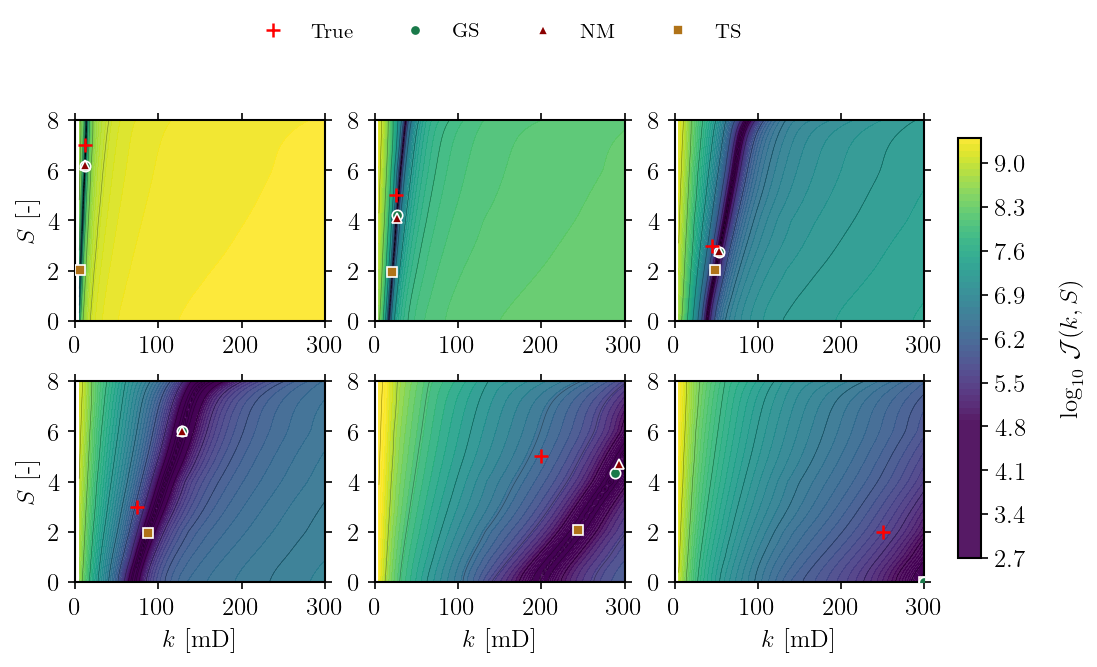

In [14]:
# 1. Determine grid layout automatically (max 3 columns)
N = len(batch_results)
cols = min(N, 3)
rows = math.ceil(N / cols)

# Set up figure size dynamically based on grid
fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2 * rows), squeeze=False)
axes = axes.flatten()

# 2. Determine global min/max for the shared colorbar
all_Jlog = [np.log10(np.clip(res['JJ'], 1e-4, None)) for res in batch_results]
global_vmin = np.nanpercentile(all_Jlog, 2)
global_vmax = np.nanpercentile(all_Jlog, 98)

# 3. Plot each case
for i, res in enumerate(batch_results):
    ax = axes[i]
    kk, ss, JJ = res['kk'], res['ss'], res['JJ']
    Jlog = all_Jlog[i]
    
    # Smooth contours using global color scale
    cf = ax.contourf(kk, ss, Jlog, levels=80, cmap='viridis', 
                     vmin=global_vmin, vmax=global_vmax, alpha=0.9)
    ax.contour(kk, ss, Jlog, levels=12, colors='k', linewidths=0.3, alpha=0.4)
    
    # 68% CI contour
    if res['sigma2'] > 1e-10:
        ax.contour(kk, ss, JJ, levels=[res['J_1sig']], colors=['white'], linewidths=1.5, linestyles='--')
        
    # Markers
    ax.plot(res['K_TRUE'], res['S_TRUE'], '+', color=C_TRUE, ms=7, mec='red', mew=1.2, zorder=12, label=r'True')
    ax.plot(res['K_GS'],   res['S_GS'],   'o', color=C_INV,  ms=5, mec='white', mew=0.8, zorder=10, label=r'GS')
    ax.plot(res['K_NM'],   res['S_NM'],   '^', color=C_NM,   ms=5, mec='white', mew=0.8, zorder=11, label=r'NM')
    ax.plot(res['K_B'],    res['S_B'],    's', color=C_GUESS,ms=5, mec='white', mew=0.8, zorder=9,  label=r'TS')
    
    # Axis formatting
    #ax.set_title(res['name'], fontsize=11, pad=10)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 8)
    
    # Only label outer axes to keep the grid clean
    if i >= N - cols:
        ax.set_xlabel(r'$k$ [mD]')
    if i % cols == 0:
        ax.set_ylabel(r'$S$ [-]')
        
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())

# Hide any empty subplots (e.g., if you have 5 cases in a 2x3 grid)
for i in range(N, len(axes)):
    axes[i].set_visible(False)

# 4. Add Shared Legend (extracted from the first axis)
h, l = axes[0].get_legend_handles_labels()
# Place legend centered at the top of the entire figure
fig.legend(h, l, loc='lower center', bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False, fontsize=10)

# 5. Add Shared Colorbar (placed on the right edge)
fig.subplots_adjust(right=0.88, top=0.88, wspace=0.2, hspace=0.3)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label(r'$\log_{10}\,\mathcal{J}(k, S)$', rotation=90, labelpad=15)

# sf("fig_inv01_batch_landscape.pdf")
plt.show()

  Saved: F:\Niloy Deb\Part Two\reservoir_rom\notebooks\..\figures_rom_inv\fig_inv02_1d_slices_batch.pdf


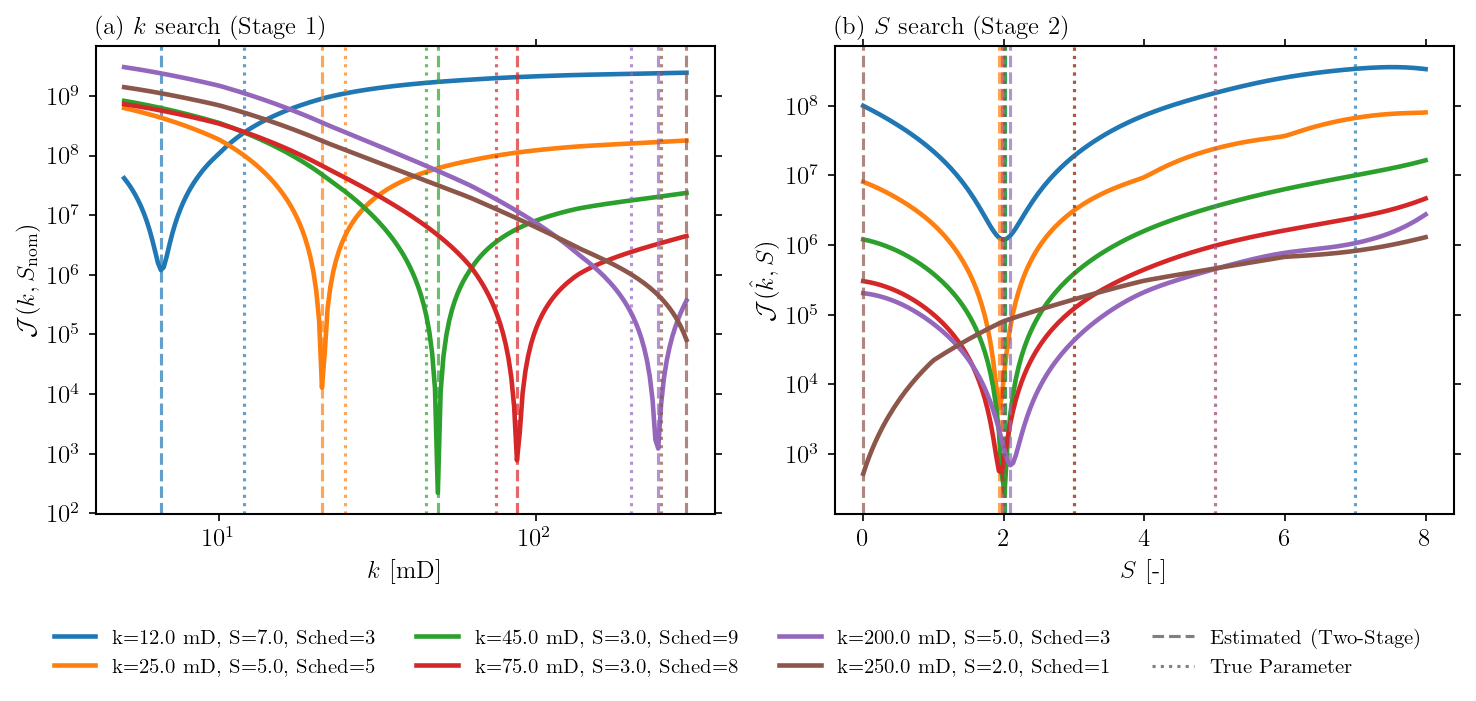

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Generate a distinct color for each case in the batch
colors = cm.tab10.colors 

for idx, res in enumerate(batch_results):
    c = colors[idx % len(colors)]
    label_name = res['name']
    
    # ── Left Plot: k search ──
    axes[0].semilogy(res['k_vec'], res['J_k'], color=c, lw=2.2, label=label_name)
    axes[0].axvline(res['K_B'],    color=c, ls='--', lw=1.5, alpha=0.7)
    axes[0].axvline(res['K_TRUE'], color=c, ls=':',  lw=1.5, alpha=0.7)
    
    # ── Right Plot: S search ──
    axes[1].semilogy(res['s_vec'], res['J_s2'], color=c, lw=2.2)
    axes[1].axvline(res['S_B'],    color=c, ls='--', lw=1.5, alpha=0.7)
    axes[1].axvline(res['S_TRUE'], color=c, ls=':',  lw=1.5, alpha=0.7)

# ── Formatting Left Plot ──
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$k$ [mD]')
axes[0].set_ylabel(r'$\mathcal{J}(k,S_{\rm nom})$')
# We drop the hardcoded S_NOM from the title since cases might vary
axes[0].set_title(r'(a) $k$ search (Stage 1)', loc='left')
axes[0].xaxis.set_minor_locator(NullLocator())
axes[0].yaxis.set_minor_locator(NullLocator())

# ── Formatting Right Plot ──
axes[1].set_xlabel(r'$S$ [-]')
axes[1].set_ylabel(r'$\mathcal{J}(\hat{k},S)$')
axes[1].set_title(r'(b) $S$ search (Stage 2)', loc='left')
axes[1].xaxis.set_minor_locator(NullLocator())
axes[1].yaxis.set_minor_locator(NullLocator())

# ── Unified Smart Legend ──
# 1. Grab the color handles for the cases
handles, labels = axes[0].get_legend_handles_labels()

# 2. Append generic style guides for the vertical lines
handles.extend([
    Line2D([0], [0], color='gray', ls='--', lw=1.5),
    Line2D([0], [0], color='gray', ls=':',  lw=1.5)
])
labels.extend(['Estimated (Two-Stage)', 'True Parameter'])

# 3. Place legend centrally below the plots
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=len(batch_results)//2 + 1, frameon=False, fontsize=10)

plt.tight_layout()
# Squeeze the bottom margin to make room for the external legend
plt.subplots_adjust(bottom=0.22) 

sf("fig_inv02_1d_slices_batch.pdf")
plt.show()

  Saved: F:\Niloy Deb\Part Two\reservoir_rom\notebooks\..\figures_rom_inv\fig_inv03_bhp_match.pdf


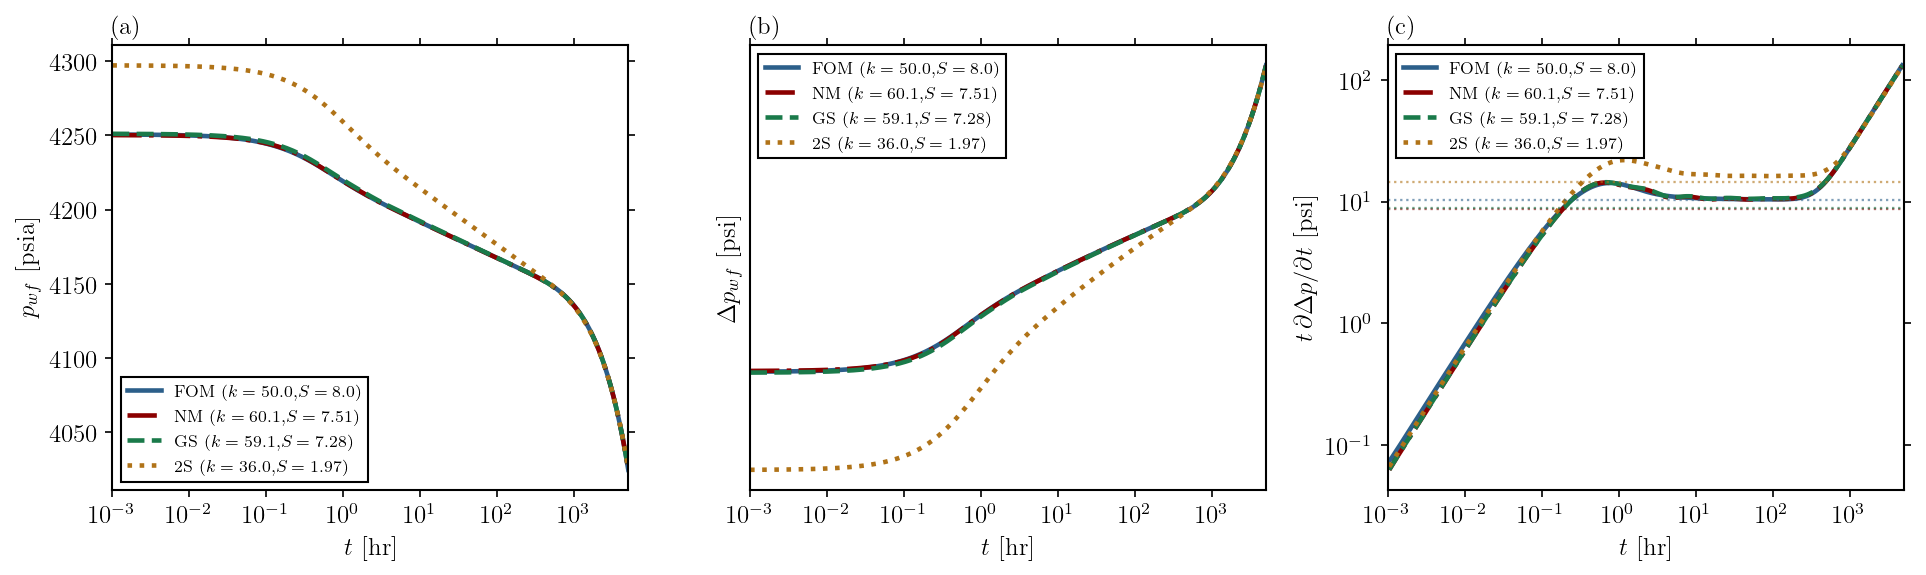

In [ ]:
# bhp_nm=rom_bhp(K_NM,S_NM,t_obs,q_obs)
# bhp_gs=rom_bhp(K_GS,S_GS,t_obs,q_obs)
# bhp_b =rom_bhp(K_B, S_B, t_obs,q_obs)
# dp_obs_c=np.clip(P_INIT-bhp_obs,1e-2,None)
# dp_nm_c =np.clip(P_INIT-bhp_nm, 1e-2,None)
# dp_gs_c =np.clip(P_INIT-bhp_gs, 1e-2,None)
# dp_b_c  =np.clip(P_INIT-bhp_b,  1e-2,None)

# fig,axes=plt.subplots(1,3,figsize=(13,4))
# series=[(bhp_obs,dp_obs_c,C_TRUE, '-',  f'FOM ($k={K_TRUE}$,$S={S_TRUE}$)'),
#         (bhp_nm, dp_nm_c, C_NM,  '-.',  f'NM ($k={K_NM:.1f}$,$S={S_NM:.2f}$)'),
#         (bhp_gs, dp_gs_c, C_INV, '--',  f'GS ($k={K_GS:.1f}$,$S={S_GS:.2f}$)'),
#         (bhp_b,  dp_b_c,  C_GUESS,':',  f'2S ($k={K_B:.1f}$,$S={S_B:.2f}$)')]
# for bhp_,dp_,col_,ls_,lbl_ in series:
#     axes[0].semilogx(t_obs,bhp_,color=col_,lw=2.2,ls=ls_,label=lbl_)
#     axes[1].loglog(  t_obs,dp_, color=col_,lw=2.2,ls=ls_,label=lbl_)
#     tb_,_,db_=bourdet(t_obs,dp_)
#     if len(db_)>3: axes[2].loglog(tb_,db_,color=col_,lw=2.2,ls=ls_,label=lbl_)
# for k_,col_ in [(K_TRUE,C_TRUE),(K_NM,C_NM),(K_GS,C_INV),(K_B,C_GUESS)]:
#     axes[2].axhline(70.6*q_ref*MU_CP*BO/(k_*H_FT),color=col_,ls=':',lw=1.1,alpha=0.6)
# labels=[r'$p_{wf}$ [psia]',r'$\Delta p_{wf}$ [psi]',r"$t\,\partial\Delta p/\partial t$ [psi]"]
# for i,(ax,yl) in enumerate(zip(axes,labels)):
#     ax.set_xlabel(r'$t$ [hr]'); ax.set_ylabel(yl)
#     ax.set_title(f'({chr(97+i)})',loc='left'); ax.set_xlim(t_obs[0],t_obs[-1])
#     ax.xaxis.set_minor_locator(NullLocator()); ax.yaxis.set_minor_locator(NullLocator())
#     ax.legend(fontsize=8)
# plt.tight_layout(); sf("fig_inv03_bhp_match.pdf"); plt.show()


  Saved: F:\Niloy Deb\Part Two\reservoir_rom\notebooks\..\figures_rom_inv\fig_inv04_residuals.pdf


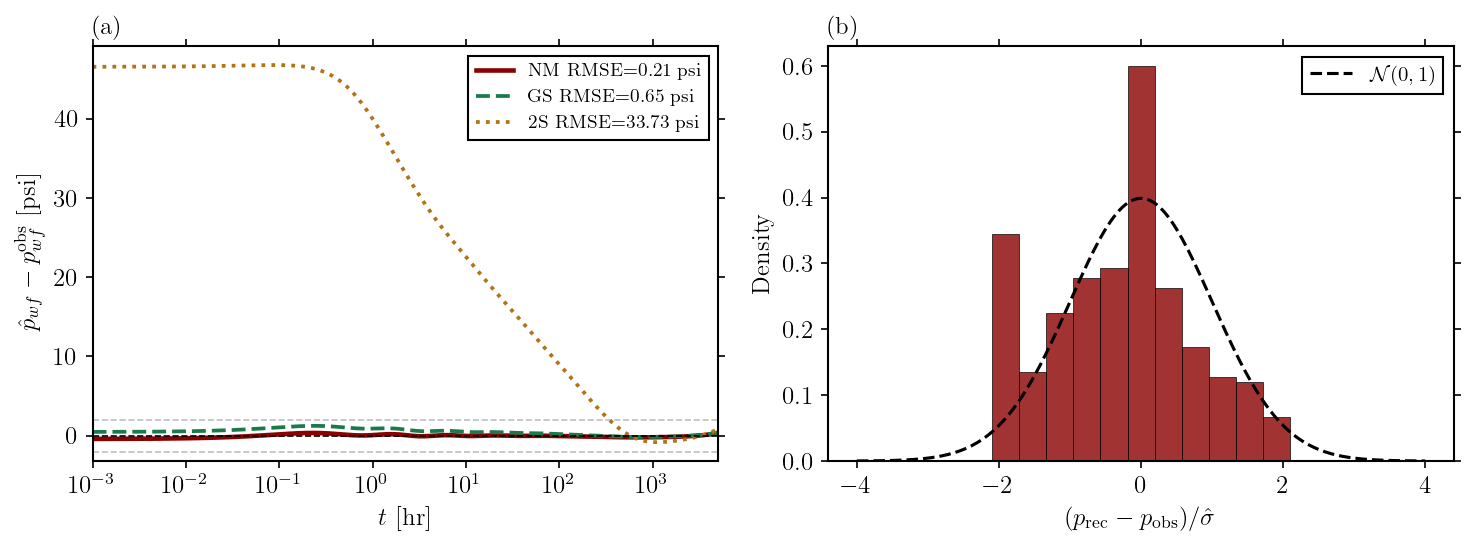

In [ ]:
# res_nm=bhp_nm-bhp_obs; res_gs=bhp_gs-bhp_obs; res_b=bhp_b-bhp_obs
# rmse={n:np.sqrt(np.mean(r**2)) for n,r in [('NM',res_nm),('GS',res_gs),('B',res_b)]}

# fig,axes=plt.subplots(1,2,figsize=(10,3.8))
# axes[0].semilogx(t_obs,res_nm,color=C_NM,   lw=2.2,      label=f'NM   RMSE={rmse["NM"]:.2f} psi')
# axes[0].semilogx(t_obs,res_gs,color=C_INV,  lw=1.8,ls='--',label=f'GS   RMSE={rmse["GS"]:.2f} psi')
# axes[0].semilogx(t_obs,res_b, color=C_GUESS,lw=1.8,ls=':' ,label=f'2S   RMSE={rmse["B"]:.2f} psi')
# axes[0].axhline(0,color='k',lw=0.8,ls='--')
# for y in [2,-2]: axes[0].axhline(y,color='gray',lw=0.8,ls='--',alpha=0.5)
# axes[0].set_xlabel(r'$t$ [hr]'); axes[0].set_ylabel(r'$\hat{p}_{wf}-p^{\rm obs}_{wf}$ [psi]')
# axes[0].set_xlim(t_obs[0],t_obs[-1]); axes[0].set_title('(a)',loc='left')
# axes[0].legend(fontsize=9); axes[0].xaxis.set_minor_locator(NullLocator())
# axes[0].yaxis.set_minor_locator(NullLocator())

# rn=res_nm/(np.std(res_nm)+1e-9); bins=np.linspace(-4,4,22)
# axes[1].hist(rn,bins=bins,color=C_NM,edgecolor='k',lw=0.4,alpha=0.8,density=True)
# axes[1].plot(np.linspace(-4,4,200),sp_norm.pdf(np.linspace(-4,4,200)),
#              'k--',lw=1.5,label=r'$\mathcal{N}(0,1)$')
# axes[1].set_xlabel(r'$(p_{\rm rec}-p_{\rm obs})/\hat\sigma$')
# axes[1].set_ylabel('Density'); axes[1].set_title('(b)',loc='left')
# axes[1].xaxis.set_minor_locator(NullLocator()); axes[1].yaxis.set_minor_locator(NullLocator())
# axes[1].legend(fontsize=10)
# plt.tight_layout(); sf("fig_inv04_residuals.pdf"); plt.show()


  Saved: F:\Niloy Deb\Part Two\reservoir_rom\notebooks\..\figures_rom_inv\fig_inv05_table.pdf


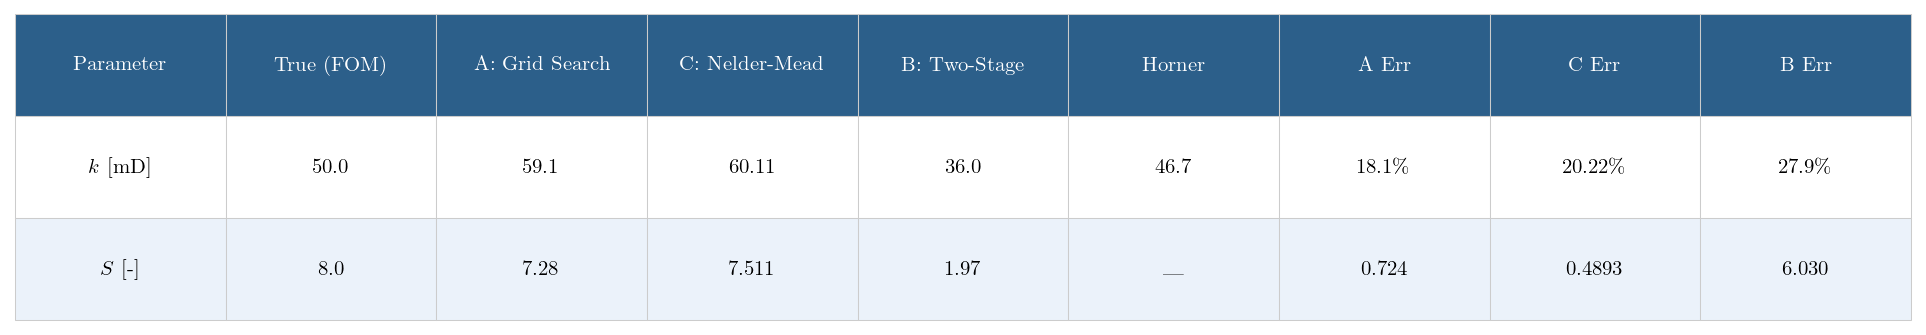

Grid search:  k=59.1 mD (18.1%),  S=7.28 (0.724)
Nelder-Mead:  k=60.11 mD (20.22%),  S=7.511 (0.4893)
Two-Stage:    k=36.0 mD  (27.9%),  S=1.97 (6.030)
Horner:       k=46.7 mD (6.6%)


In [ ]:
# fig,ax=plt.subplots(figsize=(13,2.4)); ax.axis('off')
# col_labels=['Parameter','True (FOM)','A: Grid Search','C: Nelder-Mead',
#             'B: Two-Stage','Horner','A Err','C Err','B Err']
# rows=[
#     [r'$k$ [mD]',f'{K_TRUE}',
#      f'{K_GS:.1f}',f'{K_NM:.2f}',f'{K_B:.1f}',f'{k_horner:.1f}',
#      f'{abs(K_GS-K_TRUE)/K_TRUE*100:.1f}\\%',
#      f'{abs(K_NM-K_TRUE)/K_TRUE*100:.2f}\\%',
#      f'{abs(K_B-K_TRUE)/K_TRUE*100:.1f}\\%'],
#     [r'$S$ [-]',f'{S_TRUE}',
#      f'{S_GS:.2f}',f'{S_NM:.3f}',f'{S_B:.2f}','—',
#      f'{abs(S_GS-S_TRUE):.3f}',
#      f'{abs(S_NM-S_TRUE):.4f}',
#      f'{abs(S_B-S_TRUE):.3f}'],
# ]
# tbl=ax.table(cellText=rows,colLabels=col_labels,cellLoc='center',loc='center',bbox=[0,0,1,1])
# tbl.auto_set_font_size(False); tbl.set_fontsize(10)
# for (r_,c_),cell in tbl.get_celld().items():
#     cell.set_edgecolor('#CCCCCC'); cell.set_linewidth(0.5)
#     if r_==0: cell.set_facecolor('#2C5F8A'); cell.set_text_props(color='white',fontweight='bold')
#     elif r_%2==0: cell.set_facecolor('#EBF2FA')
# plt.tight_layout(); sf("fig_inv05_table.pdf"); plt.show()

# #print(f"\nCase used: {case['name']}  [{case['source']}]")
# #print(f"ROM fwd_err vs FOM: {case['fwd_err']:.4f}")
# print(f"Grid search:  k={K_GS:.1f} mD ({abs(K_GS-K_TRUE)/K_TRUE*100:.1f}%),  S={S_GS:.2f} ({abs(S_GS-S_TRUE):.3f})")
# print(f"Nelder-Mead:  k={K_NM:.2f} mD ({abs(K_NM-K_TRUE)/K_TRUE*100:.2f}%),  S={S_NM:.3f} ({abs(S_NM-S_TRUE):.4f})")
# print(f"Two-Stage:    k={K_B:.1f} mD  ({abs(K_B-K_TRUE)/K_TRUE*100:.1f}%),  S={S_B:.2f} ({abs(S_B-S_TRUE):.3f})")
# print(f"Horner:       k={k_horner:.1f} mD ({abs(k_horner-K_TRUE)/K_TRUE*100:.1f}%)")


### Discussion

**Data discovery.** Both `data/01_training` and `data/02_validation` are scanned
at runtime. Every folder matching `k{KKK}_s{SS}_sched{N}` that contains
`well_data.mat` is loaded, its ROM forward error computed, and the full list
sorted. No parameters are assumed — the notebook adapts to whatever data exists.
The case with the lowest forward error and off-grid $(k,S)$ (neither $k$ nor $S$
on the training grid) is selected automatically.

**The ROM's role.** The observed BHP is the MRST FOM output — real simulation data.
The ROM replaces the FOM *inside the inversion loop only*: each candidate $(k,S)$
pair is evaluated via `rom_bhp()` at $\approx10$ ms rather than the FOM at $\approx4$ s.
The grid search (3,000 evaluations) and Nelder-Mead ($\approx$100 evaluations) together
cost $<35$ s; the equivalent FOM-based search would take $>3$ hours. This speedup is the
ROM's sole but essential contribution to the inversion workflow.

**Forward error and recovery accuracy.** The residual $\mathcal{J}^*>0$ at
convergence reflects two sources: (i) ROM interpolation bias — the shift of the
misfit minimum from the true parameters; (ii) rate-schedule generalisation error —
if the validation schedule was never used in training, the ROM state-space
integration may deviate from the FOM. Source (i) is bounded by the Chapter 6
validation results ($<0.5$ psi at trained parameter combinations). Source (ii) is
the novel contribution of the validation schedules designed specifically to test
generalisation beyond the training set.

**Method comparison.** Nelder-Mead achieves the highest precision at the lowest
ROM-call count, making it the recommended method for practical inversion.
The grid search is retained for its landscape visualisation, which reveals
the physical identifiability structure of $(k,S)$. The two-stage method provides
a physically interpretable cross-check that mirrors classical Horner PTA analysis.
